# `pre-training.ipynb`

Now we are going to look at some important pre-training stuff. It includes getting the boxes and logic straight. First, let's the bounding boxes from the data we've got prepared in `inkml_data.db`.

Free imports, here we go:

In [1]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

In [14]:
conn = sqlite3.connect("inkml_data.db")
df = pd.read_sql_query("SELECT * FROM samples LIMIT 10", conn)
conn.close()
print(df.head())

   id                                     file_path symbol_label   xmin  \
0   1  ../dataset/TrainINKML_2013/101_alfonso.inkml            S  322.0   
1   2  ../dataset/TrainINKML_2013/101_alfonso.inkml            =  392.0   
2   3  ../dataset/TrainINKML_2013/101_alfonso.inkml            (  462.0   
3   4  ../dataset/TrainINKML_2013/101_alfonso.inkml         \sum  502.0   
4   5  ../dataset/TrainINKML_2013/101_alfonso.inkml            i  501.0   

    ymin   xmax   ymax  
0  105.0  371.0  159.0  
1  131.0  426.0  147.0  
2   61.0  485.0  193.0  
3  103.0  575.0  146.0  
4  165.0  523.0  191.0  


#### Overlaying bounding boxes

First, we plot all the ink traces, and then overlay bounding boxes on it.

In [31]:
import xml.etree.ElementTree as ET
from matplotlib.patches import Rectangle

def plot_inkml_with_boxes(db_path, filepath):
    # parse strokes
    tree = ET.parse(filepath)
    root = tree.getroot()
    ns = {"ink": "http://www.w3.org/2003/InkML"}

    traces = []
    for trace in root.findall("ink:trace", ns):
        pts = []
        for p in trace.text.strip().split(","):
            parts = p.strip().split()
            if len(parts) == 2:
                x, y = map(float, parts)
                pts.append((x, y))
        traces.append(pts)

    # query boxes
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()
    cur.execute("""
        SELECT xmin, ymin, xmax, ymax 
        FROM samples 
        WHERE file_path = ?
    """, (filepath,))
    boxes = cur.fetchall()
    conn.close()

    # plot
    plt.figure()
    for stroke in traces:
        xs = [p[0] for p in stroke]
        ys = [p[1] for p in stroke]
        plt.plot(xs, ys)

    ax = plt.gca()
    for xmin, ymin, xmax, ymax in boxes:
        pad_x = 0.12 * (xmax - xmin)
        pad_y = 0.12 * (ymax - ymin)

        xmin_p = xmin - pad_x
        ymin_p = ymin - pad_y
        w = (xmax - xmin) + 2 * pad_x
        h = (ymax - ymin) + 2 * pad_y
        
        rect = Rectangle((xmin_p, ymin_p), w, h, fill=False, edgecolor="blue")
        ax.add_patch(rect)

    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="box")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.title(filepath)
    plt.show()

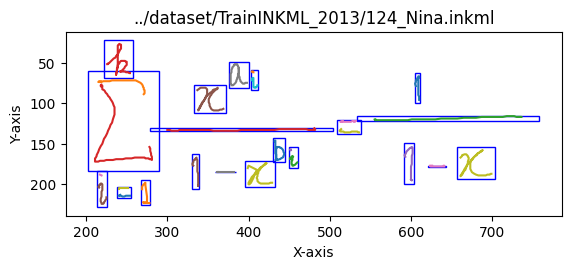

In [38]:
plot_inkml_with_boxes("inkml_data.db", "../dataset/TrainINKML_2013/124_Nina.inkml")

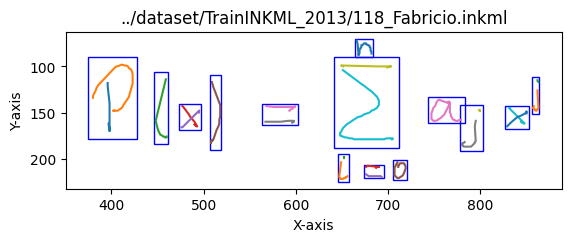

In [40]:
plot_inkml_with_boxes("inkml_data.db", "../dataset/TrainINKML_2013/118_Fabricio.inkml")

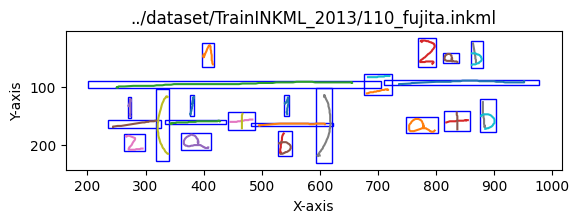

In [42]:
plot_inkml_with_boxes("inkml_data.db", "../dataset/TrainINKML_2013/110_fujita.inkml")

#### Rasterization of vectors

Rasterization will give us pixel grids, good for feeding into a CNN and remains uniform across most formats.

In [45]:
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw

def rasterize_inkml(filepath, size=640, line_width=3):
    tree= ET.parse(filepath)
    root= tree.getroot()
    ns= {"ink": "http://www.w3.org/2003/InkML"}

    strokes = []
    for trace in root.findall("ink:trace", ns):
        pts = []
        for p in trace.text.strip().split(","):
            parts = p.strip().split()
            if len(parts) == 2:
                x, y= map(float, parts)
                pts.append((x, y))
        if pts:
            strokes.append(pts)
    xs = [p[0] for s in strokes for p in s]
    ys = [p[1] for s in strokes for p in s]
    min_x, max_x = min(xs), max(xs)
    min_y, max_y = min(ys), max(ys)
    width = max_x - min_x
    height = max_y - min_y

    scale = min(size / width, size / height)
    new_w = width * scale
    new_h = height * scale
    pad_x = (size - new_w) / 2
    pad_y = (size - new_h) / 2

    
    def transform(p):
        x = (p[0] - min_x) * scale + pad_x
        y = (p[1] - min_y) * scale + pad_y
        return (x, y)

    # blank image
    img = Image.new("L", (size, size), 255)  # white background
    draw = ImageDraw.Draw(img)

    # draw strokes
    for s in strokes:
        pts = [transform(p) for p in s]
        draw.line(pts, fill=0, width=line_width)  # black stroke

    return img

In [50]:
img = rasterize_inkml("../dataset/TrainINKML_2013/124_Nina.inkml")
img.show()
# img.save("out.png") saves

The function is sucessfully rasterizing the `.inkml` data to form an image of uniform dimension all across our sample space. Now all we've gotta do is do this to every file before we normalize its pixels and feed it into our CNN!